## Import Cleaned Data and Merge Latest Data

**Steps**:
- Import various trade files
- Change formatting into per trade instead of daily settlement (keeping both clean versions though)
- Plot each quarter series individually (with faded market data if necessary)
- Review the statistics of successful and unsuccessful trades (advise potential stop-loss positions)

In [1]:
# Libraries
import pandas as pd 
import numpy as np 
import statistics as stats 
import matplotlib.pyplot as plt 
import math 

# Need to reindex to trading days 
import pandas_market_calendars as mcal

In [2]:
# Import new data a reformat ready for merging
df = pd.read_csv(r".\Trade_Data\Trade_data_update.csv", engine="python")

# Rename columns for easier handling
cols = [
    "Date", "Stamp", "ID", 
    "ES_signal", "ES_Open_Price", 
    "NQ_signal", "NQ_Open_Price", 
    "ZN_signal", "ZN_Open_Price", 
    "FGBL_signal", "FGBL_Open_Price", 
    "6E_signal", "6E_Open_Price", 
    "6J_signal", "6J_Open_Price"
    ] 
df.columns = cols 

# Drop unnecessary columns and add quarter columns
df["Quarter"] = "2026Q2" 
cols = [
    "Date", "Quarter",
    "ES_signal", "ES_Open_Price", 
    "NQ_signal", "NQ_Open_Price", 
    "ZN_signal", "ZN_Open_Price", 
    "FGBL_signal", "FGBL_Open_Price", 
    "6E_signal", "6E_Open_Price", 
    "6J_signal", "6J_Open_Price"
    ]
df = df[cols]

# Handle index 
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True) 
df["Date"] = df["Date"] + pd.offsets.BDay(1) 
df = df.dropna(subset=["Date"])
df = df.set_index("Date") 
df = df.sort_index()

# Change string signal to polar signals 
mapping = {np.nan:0, "BULLISH": 1, "BEARISH": -1, "ENDOFSERIES":0}
tickers = ["ES", "NQ", "ZN", "FGBL", "6E", "6J"]
for tick in tickers:
    df[f"{tick}_signal"] = df[f"{tick}_signal"].map(mapping) 
    df[f"{tick}_signal"] = df[f"{tick}_signal"].ffill().fillna(0).astype(int)
    df[f"{tick}_Open_Price"] = df[f"{tick}_Open_Price"].ffill().astype(float) # Only impacting last traded day

# Fix calendar
cme = mcal.get_calendar("CME_Equity")
schedule = cme.schedule(start_date=df.index.min(),
                        end_date=df.index.max())
trading_days = schedule.index
df = df.reindex(trading_days)

# Isolate new data from 2026-06-03
df = df.loc["2026-06-03":]

# Save to csv for use 
df.reset_index().to_csv(r".\Trade_Data\Trade_data_update_cleaned.csv", index=False)

# Preview dataframe 
df 

,Quarter,ES_signal,ES_Open_Price,NQ_signal,NQ_Open_Price,ZN_signal,ZN_Open_Price,FGBL_signal,FGBL_Open_Price,6E_signal,6E_Open_Price,6J_signal,6J_Open_Price
2026-06-03,2026Q2,1,7628.00,-1,30741.75,-1,109.765625,1,126.0,-1,1.16365,1,0.006262
2026-06-04,2026Q2,1,7539.75,1,30453.00,-1,109.390625,0,125.5,-1,1.16040,-1,0.006254
2026-06-05,2026Q2,1,7589.50,1,30414.00,-1,109.593750,0,125.5,-1,1.16170,-1,0.006255
2026-06-08,2026Q2,1,7368.00,1,28844.50,-1,109.046875,0,125.5,-1,1.15195,-1,0.006243
2026-06-09,2026Q2,1,7412.75,1,29435.00,-1,108.953125,0,125.5,-1,1.15385,-1,0.006247
2026-06-10,2026Q2,-1,7380.00,1,29094.75,1,109.234375,0,125.5,-1,1.15435,-1,0.006237
2026-06-11,2026Q2,1,7259.25,1,28455.00,1,109.015625,0,125.5,0,1.15375,0,0.006230
2026-06-12,2026Q2,-1,7397.50,1,29456.75,1,109.671875,0,125.5,0,1.15375,0,0.006230
2026-06-15,2026Q2,-1,7480.00,1,29907.00,1,109.781250,0,125.5,0,1.15375,0,0.006230
2026-06-16,2026Q2,0,7480.00,0,29907.00,0,109.781250,0,125.5,0,1.15375,0,0.006230


**Import both dataframes and merge for good copy**

In [3]:
# Old dataframe 
df_old = pd.read_csv(r".\Trade_Data\Trade_data.csv", engine="python", index_col=0, parse_dates=True) 

# New dataframe 
df_new = pd.read_csv(r".\Trade_Data\Trade_data_update_cleaned.csv", engine="python", index_col=0, parse_dates=True) 

# Create final dataframe 
df = df_old.copy() 

# Ready new dataframe for merging
df_new[["FGBL_signal", "FGBL_Open_Price"]] = 0
df_new = df_new.rename(columns={"FGBL_signal": "FGBM_signal", "FGBL_Open_Price": "FGBM_Open_Price"})
df_new = df_new.drop(["6J_signal", "6J_Open_Price"], axis=1)

# Merge 
df.loc[df_new.index.min():] = df_new 

# Save for use 
df.reset_index().to_csv(r".\Trade_Data\Trade_data_all.csv", index=False)

**Import and process trade data into new 'per trade' appoarch**:

In [4]:
# Import data 
df = pd.read_csv(r".\Trade_Data\Trade_data_all.csv", engine="python", parse_dates=True, index_col=0) 

# Preview data 
df.head() 

,Quarter,ES_signal,ES_Open_Price,NQ_signal,NQ_Open_Price,ZN_signal,ZN_Open_Price,FGBM_signal,FGBM_Open_Price,6E_signal,6E_Open_Price
index,,,,,,,,,,,
2025-06-23,2025Q3,1,5964.00,0,NaN,0,NaN,1,117.79,-1,1.15425
2025-06-24,2025Q3,1,6078.00,0,NaN,0,NaN,1,117.83,-1,1.16400
2025-06-25,2025Q3,1,6144.75,0,NaN,0,NaN,1,117.60,1,1.15586
2025-06-26,2025Q3,1,6144.75,0,NaN,0,NaN,1,117.75,1,1.17190
2025-06-27,2025Q3,1,6197.50,0,NaN,0,NaN,1,117.81,1,1.17610


In [7]:
# Function for analysing trading record 
def create_trade_record(df, tick): 

    # Log
    trades = [] 

    # Assign series 
    signal_col = f"{tick}_signal" 
    price_col = f"{tick}_Open_Price"

    # Initialize 
    current_signal = 0
    open_date = None 
    close_date = None 
    trade_no = 1 
    open_idx = None

    for date, row in df.iterrows(): 

        signal = row[signal_col] 
        price = row[price_col] 

        # Skip missing signals
        if pd.isna(signal):
            continue 

        # No position currently 
        if current_signal == 0: 

            if signal != 0:
                current_signal = signal 
                open_date = date 
                open_price = price 
                open_quarter = row["Quarter"]
                open_idx = df.index.get_loc(date)

        # Currently in a position 
        else:

            # Close only 
            if signal == 0: 

                close_idx = df.index.get_loc(date) 

                trades.append({
                    "Trade No": trade_no,
                    "Quarter": open_quarter,
                    "Open Date": open_date, 
                    "Open Price": open_price,
                    "Close Date": date,
                    "Close Price": price, 
                    "Trading Days": close_idx - open_idx,
                    "Type": "long" if current_signal == 1 else "short",
                    "Return": (
                        (price / open_price - 1)
                        if current_signal == 1
                        else (open_price / price -1)
                    ),
                    "Log_Return": (
                        np.log(price / open_price)
                        if current_signal == 1 
                        else np.log(open_price / price)
                    ),
                    "Market_Return": (
                        (price / open_price - 1)
                    ),
                    "Market_Log_Return": (
                        np.log(price / open_price)
                    )
                })

                trade_no += 1 
                current_signal = 0 
            
            # Reverse position 
            elif signal != current_signal: 

                close_idx = df.index.get_loc(date)

                # Close old trade 
                trades.append({
                    "Trade No": trade_no,
                    "Quarter": open_quarter,
                    "Open Date": open_date, 
                    "Open Price": open_price,
                    "Close Date": date,
                    "Close Price": price, 
                    "Trading Days": close_idx - open_idx,
                    "Type": "long" if current_signal == 1 else "short",
                    "Return": (
                        (price / open_price - 1)
                        if current_signal == 1
                        else (open_price / price -1)
                    ),
                    "Log_Return": (
                        np.log(price / open_price)
                        if current_signal == 1 
                        else np.log(open_price / price)
                    ),
                    "Market_Return": (
                        (price / open_price - 1)
                    ),
                    "Market_Log_Return": (
                        np.log(price / open_price)
                    )
                })

                trade_no += 1 

                # Open new trade immediately 
                current_signal = signal 
                open_date = date 
                open_price = price 
                open_quarter = row["Quarter"]
                open_idx = df.index.get_loc(date)

    # Leave final trade open if necessary
    if current_signal != 0:
        trades.append({
            "Trade No": trade_no,
            "Quarter": open_quarter,
            "Open Date": open_date,
            "Open Price": open_price,
            "Close Date": pd.NaT,
            "Close Price": None,
            "Trading Days": None,
            "Type": "long" if current_signal == 1 else "short",
            "Return": (
                (price / open_price - 1)
                if current_signal == 1
                else (open_price / price -1)
            ),
            "Log_Return": (
                np.log(price / open_price)
                if current_signal == 1 
                else np.log(open_price / price)
            ),
            "Market_Return": (
                (price / open_price - 1)
            ),
            "Market_Log_Return": (
                np.log(price / open_price)
            )
        })

    return pd.DataFrame(trades).set_index(["Trade No"]) 

# Tickers 
tickers = ["ES", "NQ", "ZN", "FGBM", "6E"]

# Create trade data 
all_trades = []
for ticker in tickers:
    trades = create_trade_record(df, ticker)
    trades.insert(0, "Ticker", ticker) 

    # Compute cum log returns
    trades["Cum_Log_Return"] = trades["Log_Return"].cumsum()
    trades["Cum_Market_Log_Return"] = trades["Market_Log_Return"].cumsum()

    # Add equity curves
    trades["Equity_Curve"] = np.exp(trades["Cum_Log_Return"])
    trades["Market_Equity_Curve"] = np.exp(trades["Cum_Market_Log_Return"])

    # Drawdown
    trades["Peak_Return"] = trades["Equity_Curve"].cummax()
    trades["Drawdown"] = trades["Equity_Curve"] / trades["Peak_Return"] - 1

    all_trades.append(trades)

# Compile and preview
all_trades = pd.concat(all_trades, ignore_index=True)
all_trades

,Ticker,Quarter,Open Date,Open Price,Close Date,Close Price,Trading Days,Type,Return,Log_Return,Market_Return,Market_Log_Return,Cum_Log_Return,Cum_Market_Log_Return,Equity_Curve,Market_Equity_Curve,Peak_Return,Drawdown
0,ES,2025Q3,2025-06-23,5964.00000,2025-07-07,6307.75000,10,long,0.057637,0.056038,0.057637,0.056038,0.056038,0.056038,1.057637,1.057637,1.057637,0.000000
1,ES,2025Q3,2025-07-07,6307.75000,2025-07-14,6274.00000,5,short,0.005379,0.005365,-0.005351,-0.005365,0.061403,0.050673,1.063327,1.051979,1.063327,0.000000
2,ES,2025Q3,2025-07-14,6274.00000,2025-09-05,6515.00000,39,long,0.038412,0.037693,0.038412,0.037693,0.099096,0.088366,1.104172,1.092388,1.104172,0.000000
3,ES,2025Q3,2025-09-05,6515.00000,2025-09-08,6483.75000,1,short,0.004820,0.004808,-0.004797,-0.004808,0.103904,0.083558,1.109494,1.087148,1.109494,0.000000
4,ES,2025Q3,2025-09-08,6483.75000,2025-09-17,6669.50000,7,long,0.028649,0.028246,0.028649,0.028246,0.132150,0.111803,1.141279,1.118293,1.141279,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,6E,2026Q2,2026-04-29,1.17385,2026-04-30,1.17005,1,short,0.003248,0.003242,-0.003237,-0.003242,-0.039676,-0.003744,0.961101,0.996263,1.018599,-0.056448
126,6E,2026Q2,2026-04-30,1.17005,2026-05-05,1.17155,3,long,0.001282,0.001281,0.001282,0.001281,-0.038394,-0.002463,0.962333,0.997540,1.018599,-0.055238
127,6E,2026Q2,2026-05-05,1.17155,2026-05-06,1.17160,1,short,-0.000043,-0.000043,0.000043,0.000043,-0.038437,-0.002420,0.962292,0.997582,1.018599,-0.055279
128,6E,2026Q2,2026-05-06,1.17160,2026-05-19,1.16735,9,long,-0.003628,-0.003634,-0.003628,-0.003634,-0.042071,-0.006055,0.958802,0.993964,1.018599,-0.058705


**Analyse each ticker**

In [45]:
# -----------------------------
# 1. Ensure numeric types
# -----------------------------
cols = ["Return", "Log_Return", "Trading Days", "Market_Log_Return"]
all_trades[cols] = all_trades[cols].apply(pd.to_numeric, errors="coerce")

# -----------------------------
# 2. Base quarterly stats
# -----------------------------
quarter_summary = all_trades.groupby(["Ticker", "Quarter"]).agg(
    Trades=("Return", "count"),
    Mean_Return=("Return", "mean"),
    Volatility=("Return", "std"),
    Mean_Log_Return=("Log_Return", "mean"),
    Hit_Rate=("Return", lambda x: (x > 0).mean()),
    Avg_Length=("Trading Days", "mean"),
    Min_Length=("Trading Days", "min"),
    Max_Length=("Trading Days", "max"),
    Sharpe=("Log_Return", lambda x: (
    (x.mean() / x.std()) * np.sqrt(all_trades.loc[x.index, "Trading Days"].sum()) if x.std() != 0 else np.nan)),
    Max_Drawdown=("Drawdown", "min"),
    Total_Return=("Equity_Curve", "last")  # simple proxy for growth
)

quarter_corr = (
    all_trades
    .groupby(["Ticker", "Quarter"])
    .apply(lambda g: g["Log_Return"].corr(g["Market_Log_Return"]))
    .rename("Market_Corr")
)
quarter_summary = quarter_summary.join(quarter_corr)

# -----------------------------
# 3. Output
# -----------------------------
quarter_summary

C:\Users\tim_d\AppData\Local\Temp\ipykernel_22380\321426466.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["Log_Return"].corr(g["Market_Log_Return"]))


Trades  Mean_Return  Volatility  Mean_Log_Return  Hit_Rate  \
Ticker Quarter                                                               
6E     2025Q3        6     0.001362    0.009379         0.001325  0.166667   
       2025Q4        9    -0.002194    0.006908        -0.002218  0.333333   
       2026Q1        5    -0.007368    0.014629        -0.007483  0.400000   
       2026Q2        8     0.002418    0.008485         0.002384  0.500000   
ES     2025Q3        5     0.026980    0.022533         0.026430  1.000000   
       2025Q4        9     0.004334    0.015470         0.004219  0.555556   
       2026Q1        7    -0.010069    0.017449        -0.010253  0.428571   
       2026Q2       16     0.003775    0.024166         0.003502  0.375000   
FGBM   2025Q3        3    -0.002748    0.002659        -0.002754  0.000000   
NQ     2026Q1        8    -0.005985    0.010608        -0.006053  0.375000   
       2026Q2       21     0.011334    0.023147         0.011025  0.761905   
ZN     2025Q4        8     0.001751    0.004489         0.001741  0.750000   
       2026Q1        7     0.001765    0.006441         0.001746  0.571429   
       2026Q2       18     0.001629    0.004618         0.001617  0.666667   

                Avg_Length  Min_Length  Max_Length    Sharpe  Max_Drawdown  \
Ticker Quarter                                                               
6E     2025Q3     9.666667           2          25  1.084762     -0.010422   
       2025Q4     5.888889           1          25 -2.332473     -0.015363   
       2026Q1    10.600000           1          19 -3.674264     -0.044123   
       2026Q2     6.000000           1          17  1.957256     -0.011181   
ES     2025Q3    12.400000           1          39  9.503788      0.000000   
       2025Q4     6.333333           1          29  2.072703     -0.024940   
       2026Q1     8.285714           2          14 -4.435705     -0.084521   
       2026Q2     3.437500           1          14  1.096252     -0.075176   
FGBM   2025Q3    17.666667           1          27 -7.516268     -0.002555   
NQ     2026Q1     7.250000           1          21 -4.306682     -0.053900   
       2026Q2     2.666667           1           8  3.646997     -0.024620   
ZN     2025Q4     7.125000           2          15  2.933790     -0.004006   
       2026Q1     8.285714           1          20  2.070563     -0.005812   
       2026Q2     3.111111           1           9  2.627765     -0.005899   

                Total_Return  Market_Corr  
Ticker Quarter                             
6E     2025Q3       1.007983     0.987129  
       2025Q4       0.988063     0.711409  
       2026Q1       0.951779     0.945854  
       2026Q2       0.970104     0.411061  
ES     2025Q3       1.141279     0.995415  
       2025Q4       1.185449    -0.230835  
       2026Q1       1.103349    -0.018249  
       2026Q2       1.166928     0.683342  
FGBM   2025Q3       0.991771     0.812834  
NQ     2026Q1       0.952731     0.757593  
       2026Q2       1.200928     0.712629  
ZN     2025Q4       1.014023     0.032230  
       2026Q1       1.026490     0.759189  
       2026Q2       1.056813    -0.696179

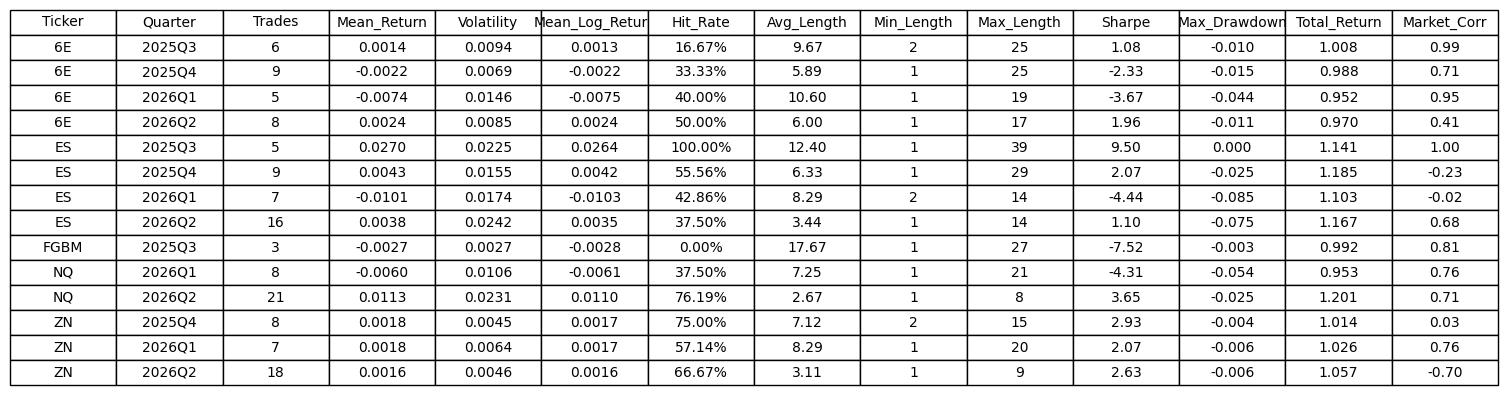

In [60]:
# Create table output for Quarterly Stats 
table_df = quarter_summary.copy().reset_index() 

# Format output numbers
table_df["Mean_Return"] = table_df["Mean_Return"].map(lambda x: f"{x:.4f}")
table_df["Volatility"] = table_df["Volatility"].map(lambda x: f"{x:.4f}")
table_df["Mean_Log_Return"] = table_df["Mean_Log_Return"].map(lambda x: f"{x:.4f}")
table_df["Hit_Rate"] = table_df["Hit_Rate"].map(lambda x: f"{x:.2%}")
table_df["Avg_Length"] = table_df["Avg_Length"].map(lambda x: f"{x:.2f}")
table_df["Sharpe"] = table_df["Sharpe"].map(lambda x: f"{x:.2f}")
table_df["Max_Drawdown"] = table_df["Max_Drawdown"].map(lambda x: f"{x:.3f}")
table_df["Total_Return"] = table_df["Total_Return"].map(lambda x: f"{x:.3f}")
table_df["Market_Corr"] = table_df["Market_Corr"].map(lambda x: f"{x:.2f}")

# Preview 
table_df

# Create output figure
fig, ax = plt.subplots(figsize=(16,4))
ax.axis("off")

# Figure contents/format
tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.get_tightbbox()
tbl.scale(1.2, 1.5)

# Save figure
save_string = "quarter_stats_all"
plt.savefig(fr".\Figures\{save_string}.pdf", bbox_inches="tight", pad_inches=0.01)
plt.savefig(fr".\Figures\{save_string}.jpg", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()

**Review Short Performance**

In [ ]:
# -----------------------------
# 1. Base short/long stats
# -----------------------------
short_summary = all_trades.groupby(["Ticker", "Type"]).agg(
    Trades=("Return", "count"),
    Mean_Return=("Return", "mean"),
    Volatility=("Return", "std"),
    Mean_Log_Return=("Log_Return", "mean"),
    Hit_Rate=("Return", lambda x: (x > 0).mean()),
    Avg_Length=("Trading Days", "mean"),
    Min_Length=("Trading Days", "min"),
    Max_Length=("Trading Days", "max"),
    Sharpe=("Log_Return", lambda x: (
    (x.mean() / x.std()) * np.sqrt(all_trades.loc[x.index, "Trading Days"].sum()) if x.std() != 0 else np.nan)),
)

short_summary

Trades  Mean_Return  Volatility  Mean_Log_Return  Hit_Rate  \
Ticker Type                                                                
6E     long       15    -0.001528    0.012669        -0.001604  0.400000   
       short      13    -0.000473    0.004737        -0.000484  0.307692   
ES     long       19     0.010305    0.027428         0.009907  0.578947   
       short      18    -0.001777    0.014678        -0.001881  0.444444   
FGBM   long        2    -0.003100    0.003661        -0.003108  0.000000   
       short       1    -0.002045         NaN        -0.002047  0.000000   
NQ     long       15     0.013083    0.027246         0.012665  0.666667   
       short      14    -0.000437    0.010828        -0.000492  0.642857   
ZN     long       17     0.001256    0.004669         0.001245  0.588235   
       short      16     0.002145    0.005148         0.002130  0.750000   

              Avg_Length  Min_Length  Max_Length    Sharpe  
Ticker Type                                                 
6E     long     9.266667           1          25 -1.487167  
       short    5.615385           1          25 -0.874650  
ES     long     9.578947           1          39  4.960653  
       short    2.777778           1          11 -0.904597  
FGBM   long    26.000000          25          27 -6.103276  
       short    1.000000           1           1       NaN  
NQ     long     6.000000           1          21  4.508617  
       short    1.714286           1           5 -0.221993  
ZN     long     4.705882           1          13  2.393050  
       short    5.687500           1          20  3.957873

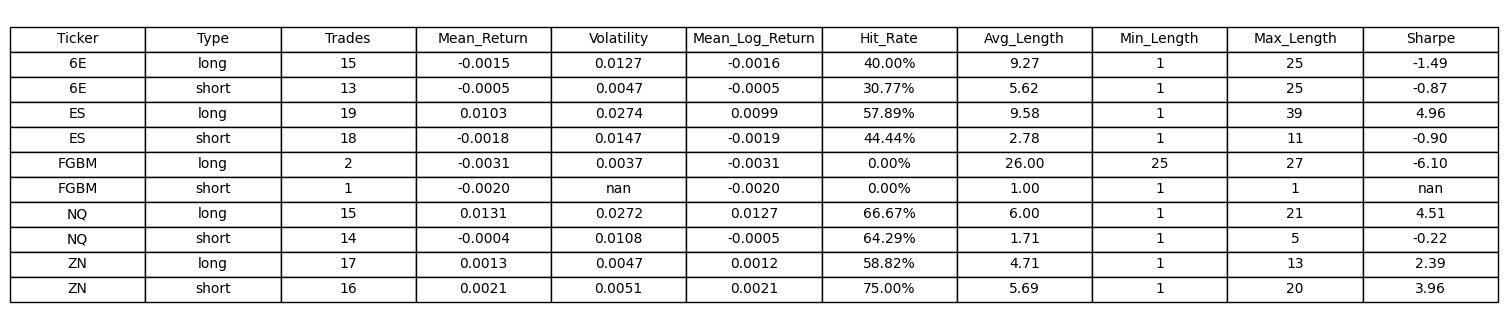

In [62]:
# Create table output for Quarterly Stats 
table_df = short_summary.copy().reset_index() 

# Format output numbers
table_df["Mean_Return"] = table_df["Mean_Return"].map(lambda x: f"{x:.4f}")
table_df["Volatility"] = table_df["Volatility"].map(lambda x: f"{x:.4f}")
table_df["Mean_Log_Return"] = table_df["Mean_Log_Return"].map(lambda x: f"{x:.4f}")
table_df["Hit_Rate"] = table_df["Hit_Rate"].map(lambda x: f"{x:.2%}")
table_df["Avg_Length"] = table_df["Avg_Length"].map(lambda x: f"{x:.2f}")
table_df["Sharpe"] = table_df["Sharpe"].map(lambda x: f"{x:.2f}")

# Preview 
table_df

# Create output figure
fig, ax = plt.subplots(figsize=(16,4))
ax.axis("off")

# Figure contents/format
tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.get_tightbbox()
tbl.scale(1.2, 1.5)

# Save figure
save_string = "quarter_stats_short_long"
plt.savefig(fr".\Figures\{save_string}.pdf", bbox_inches="tight", pad_inches=0.01)
plt.savefig(fr".\Figures\{save_string}.jpg", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()